# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hapepaAhmed/my-capstone-project/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!pip install -q huggingface_hub

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

from google.colab import userdata
from huggingface_hub import hf_hub_download

In [4]:
HF_TOKEN = userdata.get("HF_TOKEN")

In [5]:
parquet_path = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=HF_TOKEN,
)


fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

In [6]:
df = pd.read_parquet(parquet_path)

print(df.shape)

(9841378, 30)


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

## Distribution of Key Signals

Before building ranking models, the distributions of the main search signals are examined to understand their ranges, variability, and potential outliers. Heavy-tailed distributions may require normalization or transformation before modeling.

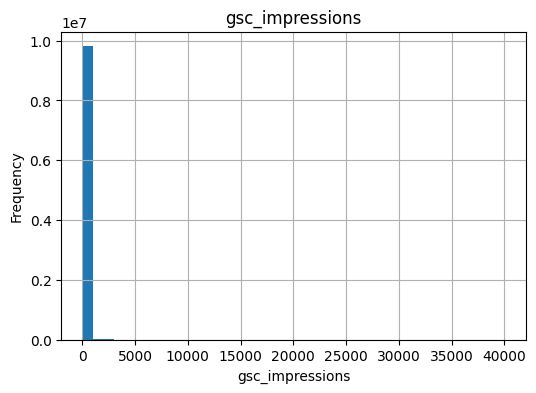

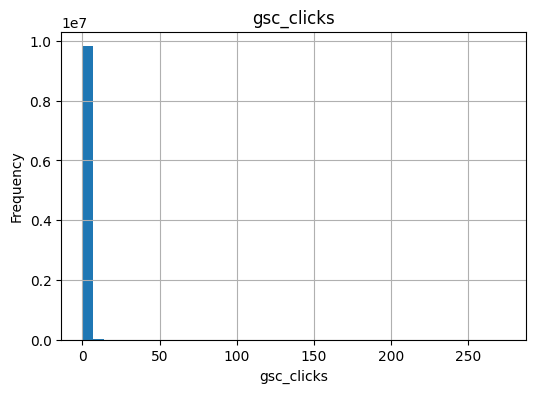

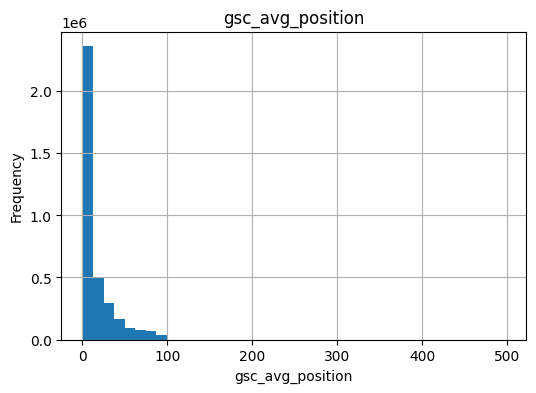

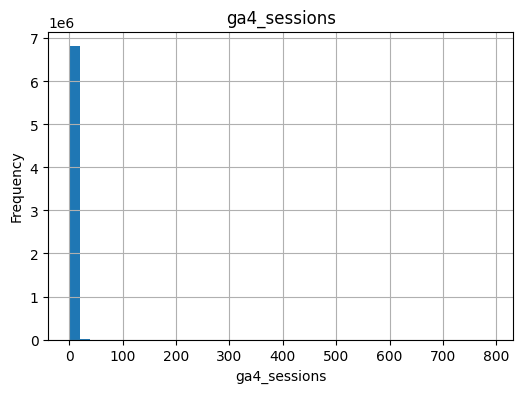

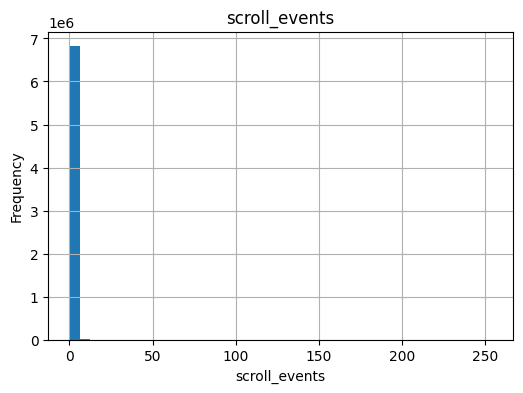

In [7]:
import matplotlib.pyplot as plt

signals = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_avg_position",
    "ga4_sessions",
    "scroll_events"
]

for col in signals:
    plt.figure(figsize=(6,4))
    df[col].hist(bins=40)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [8]:
corr = df["gsc_impressions"].corr(df["gsc_clicks"])

print(corr)


0.5966873085053721


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [9]:
corr = df["gsc_avg_position"].corr(df["gsc_clicks"])

print(corr)


-0.07262796804626172


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [10]:
corr = df["ga4_sessions"].corr(
    df["ga4_engaged_sessions"]
)

print(corr)


0.210284953135244


# **The Flag-Linked Test**


In [11]:
high_impressions = (
    df["gsc_impressions"] >
    df["gsc_impressions"].median()
)

poor_position = (
    df["gsc_avg_position"] >
    df["gsc_avg_position"].median()
)

flag = high_impressions & poor_position

print(flag.value_counts())

False    8045338
True     1796040
Name: count, dtype: int64


In [12]:
df.groupby(flag)[
    "gsc_clicks"
].mean()

,gsc_clicks
False,0.074152
True,0.125419


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.